# ch310 — Batch Normalisation

## 1. The internal covariate shift problem

As weights update during training, the distribution of each layer's inputs changes.
Deeper layers must constantly adapt to a shifting input distribution — this slows training.
**Batch Normalisation** (Ioffe & Szegedy, 2015) eliminates this by explicitly normalising
each layer's pre-activation to zero mean and unit variance during training.

---

## 2. The algorithm

For a mini-batch $\mathcal{B} = \{z^{(1)}, \ldots, z^{(B)}\}$ of pre-activations:

$$\mu_\mathcal{B} = \frac{1}{B}\sum_{i=1}^B z^{(i)}, \quad
  \sigma^2_\mathcal{B} = \frac{1}{B}\sum_{i=1}^B (z^{(i)} - \mu_\mathcal{B})^2$$

$$\hat{z}^{(i)} = \frac{z^{(i)} - \mu_\mathcal{B}}{\sqrt{\sigma^2_\mathcal{B} + \varepsilon}}$$

$$y^{(i)} = \gamma \hat{z}^{(i)} + \beta$$

$\gamma$ (scale) and $\beta$ (shift) are **learnable parameters** — the network can
undo the normalisation if it helps. $\varepsilon \approx 10^{-5}$ prevents division by zero.

*(Mean and variance: ch249–ch250. Normalisation: ch285.)*

---

## 3. Training vs inference

During training: use batch statistics $\mu_\mathcal{B}$, $\sigma^2_\mathcal{B}$.

During inference: batch size may be 1 (no reliable batch statistics).
Fix: maintain **running averages** $\mu_{\text{run}}$, $\sigma^2_{\text{run}}$ with
exponential moving average during training. Use these at inference time:

$$\mu_{\text{run}} \leftarrow \alpha \mu_{\text{run}} + (1-\alpha)\mu_\mathcal{B}$$

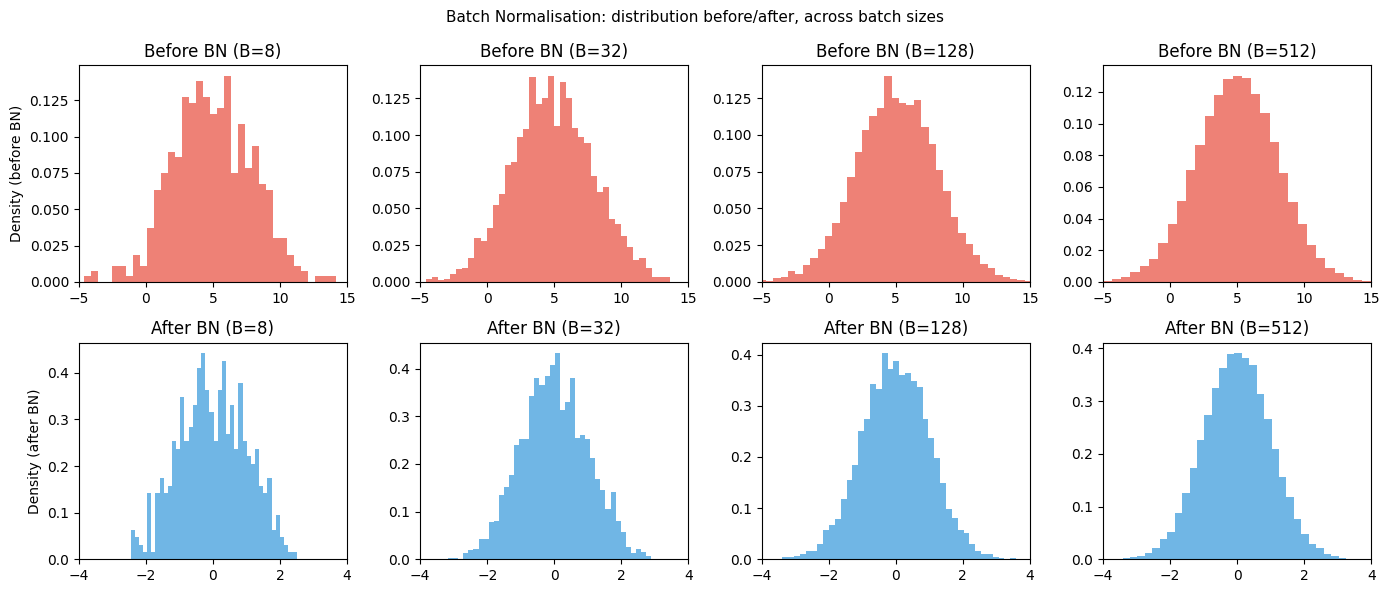

Note: small batch sizes (B=8) give noisy estimates of mean/variance.
For B<16, consider Layer Normalisation instead (used in Transformers — ch322).


In [1]:
import numpy as np
import matplotlib.pyplot as plt


class BatchNorm1D:
    """Batch normalisation for 1D activations, shape (features, batch)."""

    def __init__(self, n_features: int, eps: float = 1e-5, momentum: float = 0.1):
        self.gamma = np.ones(n_features)
        self.beta = np.zeros(n_features)
        self.eps = eps
        self.momentum = momentum
        # Running stats (for inference)
        self.running_mean = np.zeros(n_features)
        self.running_var = np.ones(n_features)
        self.cache = None

    def forward(self, Z: np.ndarray, training: bool = True) -> np.ndarray:
        """Z: shape (n_features, batch_size)"""
        if training:
            mu = Z.mean(axis=1, keepdims=True)
            var = Z.var(axis=1, keepdims=True)
            Z_hat = (Z - mu) / np.sqrt(var + self.eps)
            # Update running statistics
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mu.ravel()
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * var.ravel()
            self.cache = (Z, Z_hat, mu, var)
        else:
            Z_hat = (Z - self.running_mean[:, None]) / np.sqrt(self.running_var[:, None] + self.eps)
        return self.gamma[:, None] * Z_hat + self.beta[:, None]

    def backward(self, dY: np.ndarray) -> tuple:
        """Returns (dZ, d_gamma, d_beta)."""
        Z, Z_hat, mu, var = self.cache
        B = Z.shape[1]
        d_gamma = (dY * Z_hat).sum(axis=1)
        d_beta = dY.sum(axis=1)
        dZ_hat = dY * self.gamma[:, None]
        std_inv = 1.0 / np.sqrt(var + self.eps)
        dZ = (1.0/B) * std_inv * (
            B * dZ_hat
            - dZ_hat.sum(axis=1, keepdims=True)
            - Z_hat * (dZ_hat * Z_hat).sum(axis=1, keepdims=True)
        )
        return dZ, d_gamma, d_beta


# Visualise: activations before and after BN across layers
rng = np.random.default_rng(0)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
n_features = 64

for col, batch_size in enumerate([8, 32, 128, 512]):
    Z = rng.normal(5, 3, (n_features, batch_size))  # shifted, scaled activations
    bn = BatchNorm1D(n_features)
    Z_out = bn.forward(Z, training=True)

    axes[0, col].hist(Z.ravel(), bins=40, color='#e74c3c', alpha=0.7, density=True)
    axes[0, col].set_title(f'Before BN (B={batch_size})')
    axes[0, col].set_xlim(-5, 15)

    axes[1, col].hist(Z_out.ravel(), bins=40, color='#3498db', alpha=0.7, density=True)
    axes[1, col].set_title(f'After BN (B={batch_size})')
    axes[1, col].set_xlim(-4, 4)

axes[0, 0].set_ylabel('Density (before BN)')
axes[1, 0].set_ylabel('Density (after BN)')
plt.suptitle('Batch Normalisation: distribution before/after, across batch sizes', fontsize=11)
plt.tight_layout()
plt.savefig('ch310_batchnorm.png', dpi=120)
plt.show()

print("Note: small batch sizes (B=8) give noisy estimates of mean/variance.")
print("For B<16, consider Layer Normalisation instead (used in Transformers — ch322).")

## 4. Why BatchNorm accelerates training

1. **Higher learning rates are stable**: normalised activations prevent extreme gradients.
2. **Reduced sensitivity to initialisation**: the normalisation corrects for bad starting weights.
3. **Slight regularisation effect**: batch statistics introduce noise, similar to dropout.

## 5. Layer Norm vs Batch Norm

| | Batch Norm | Layer Norm |
|---|---|---|
| Normalises over | Batch dimension | Feature dimension |
| Works with batch size 1 | ✗ | ✓ |
| Standard use | CNNs, MLPs | Transformers, RNNs |
| Running stats needed | Yes | No |

Transformers *(ch322)* use Layer Norm because they process sequences of varying length,
often one token at a time during inference.

---

## 6. Summary

- BatchNorm normalises each feature to zero mean, unit variance within a mini-batch.
- $\gamma$ and $\beta$ are learnable: the network can restore any distribution it needs.
- Training uses batch statistics; inference uses exponential moving average.
- Enables higher LR, less sensitivity to init, slight regularisation.
- For Transformers: use Layer Norm (normalise over features, not batch).

---

## 7. Forward and backward references

**Used here:** mean and variance *(ch249–ch250)*, backpropagation *(ch306)*,
initialisation sensitivity *(ch308)*.

**This will reappear in ch322 — Transformers**, where Layer Normalisation (same principle,
different axis) is applied before each attention and feed-forward sublayer.